In [91]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


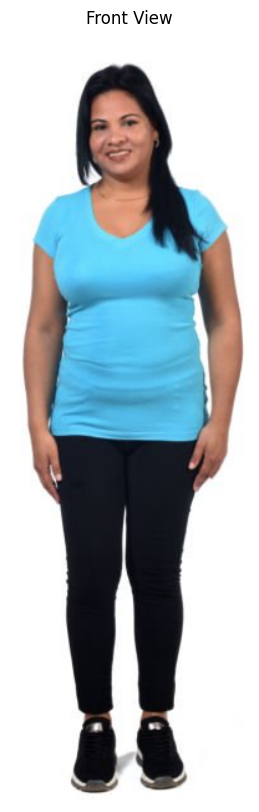

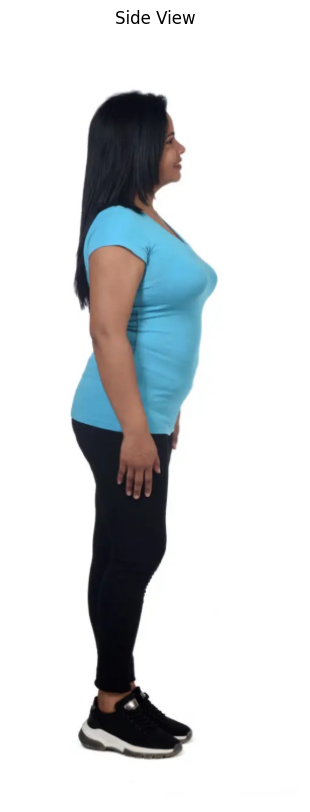

Front image shape: (760, 236, 3)
Side image shape: (762, 287, 3)


In [92]:
# MODULE 1: Setup + Image Loading
!pip install opencv-python-headless matplotlib numpy requests -q

import cv2
import numpy as np
import matplotlib.pyplot as plt
import requests
from IPython.display import display
from PIL import Image
from io import BytesIO

# Stock photos
front_path = "/content/drive/MyDrive/implementation_images/f1.png"
side_path = "/content/drive/MyDrive/implementation_images/s1.png"


def show_image(img, title="Image"):
    plt.figure(figsize=(6, 10))
    if img.ndim == 3: # Color image
        plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    elif img.ndim == 2: # Grayscale image
        plt.imshow(img, cmap='gray')
    plt.title(title)
    plt.axis('off')
    plt.show()



front_img = cv2.imread(front_path)
side_img = cv2.imread(side_path)


if front_img is not None:
    show_image(front_img, "Front View")
else:
    print("Front image could not be loaded or decoded.")

if side_img is not None:
    show_image(side_img, "Side View")
else:
    print("Side image could not be loaded or decoded.")

if front_img is not None:
    print(f"Front image shape: {front_img.shape}")
else:
    print("Front image shape: N/A (image not loaded).")

if side_img is not None:
    print(f"Side image shape: {side_img.shape}")
else:
    print("Side image shape: N/A (image not loaded).")


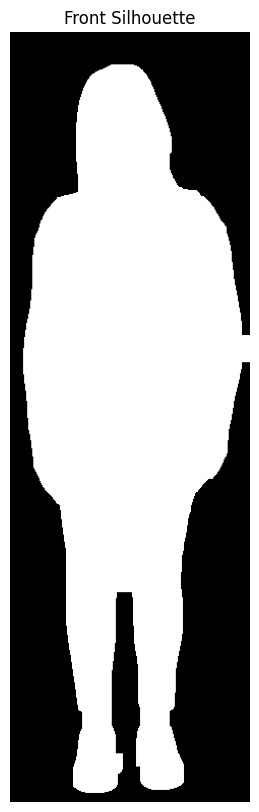

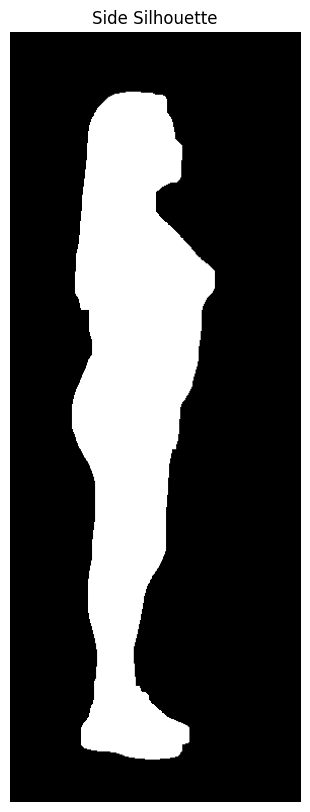

In [93]:
def extract_silhouette(img):
    # Convert to grayscale
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # Threshold - assumes light/white background
    # For THRESH_BINARY_INV with a white background, we want the threshold to be high
    # so that background pixels (e.g., >200) become 0 (black) and person pixels (e.g., <200) become 255 (white).
    _, thresh = cv2.threshold(gray, 200, 255, cv2.THRESH_BINARY_INV)

    # Bigger kernel to fill gaps from dark clothing
    kernel = np.ones((15, 15), np.uint8)
    cleaned = cv2.morphologyEx(thresh, cv2.MORPH_CLOSE, kernel)
    cleaned = cv2.morphologyEx(cleaned, cv2.MORPH_OPEN, kernel)

    # Find largest contour (the person)
    contours, _ = cv2.findContours(cleaned, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    # If no contours are found, return an empty silhouette to prevent errors
    if not contours:
        return np.zeros_like(gray), None

    largest = max(contours, key=cv2.contourArea)

    # Fill ALL holes inside the contour
    silhouette = np.zeros_like(gray)
    cv2.drawContours(silhouette, [largest], -1, 255, thickness=cv2.FILLED)

    # Flood fill from edges to catch any remaining holes
    flood = silhouette.copy()
    h, w = flood.shape
    mask = np.zeros((h+2, w+2), np.uint8)
    cv2.floodFill(flood, mask, (0, 0), 255)
    flood_inv = cv2.bitwise_not(flood)
    silhouette = cv2.bitwise_or(silhouette, flood_inv)

    return silhouette, largest

front_img = cv2.imread(front_path)
side_img = cv2.imread(side_path)

front_silhouette, front_contour = extract_silhouette(front_img)
side_silhouette, side_contour = extract_silhouette(side_img)

show_image(front_silhouette, "Front Silhouette")
show_image(side_silhouette, "Side Silhouette")

In [29]:
# Install
!pip install ultralytics -q

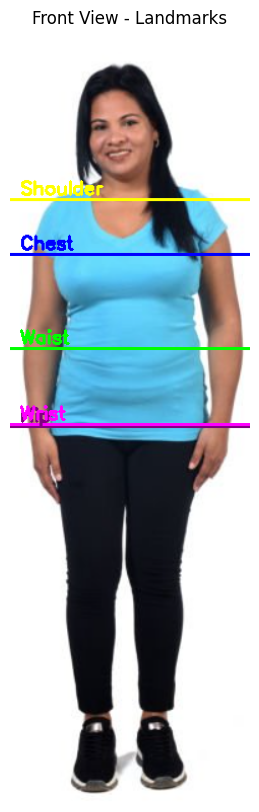

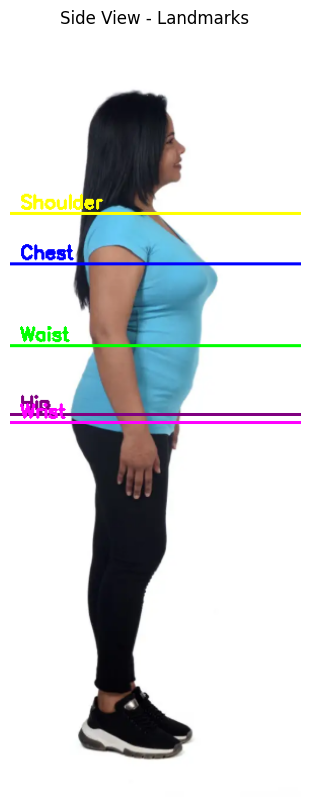

In [121]:
# MODULE 3 (YOLO): Keypoint Detection

from ultralytics import YOLO
import cv2
import numpy as np

model = YOLO("yolov8n-pose.pt")

def get_width_at_row(silhouette, y):
    row = silhouette[y, :]
    cols = np.where(row > 0)[0]
    if len(cols) == 0:
        return 0, 0, 0
    return cols[-1] - cols[0], cols[0], cols[-1]

def detect_landmarks_yolo(img, silhouette):
    h, w = img.shape[:2]
    results = model(img, verbose=False)

    if len(results) == 0 or results[0].keypoints is None:
        print("No person detected")
        return None

    kpts = results[0].keypoints.xy[0].cpu().numpy()

    shoulder_y = int((kpts[5][1] + kpts[6][1]) / 2)
    hip_y      = int((kpts[11][1] + kpts[12][1]) / 2)
    wrist_y    = int((kpts[9][1] + kpts[10][1]) / 2)
    nose_y     = int(kpts[0][1])

    neck_y    = int((nose_y + shoulder_y) / 1.8)
    chest_y   = int(neck_y + (hip_y - neck_y) * 0.27)
    waist_y   = int(chest_y + (hip_y - chest_y) * 0.55)
    arm_top_y = int(shoulder_y - (hip_y - shoulder_y) * 0.08)

    rows = np.any(silhouette > 0, axis=1)
    top = np.argmax(rows)
    bottom = len(rows) - np.argmax(rows[::-1]) - 1

    landmarks = {
        "chest_y":   chest_y,
        "waist_y":   waist_y,
        "hip_y":     hip_y,
        "arm_top_y": arm_top_y,  # fixed
        "arm_bot_y": wrist_y,
        "top":       top,
        "bottom":    bottom,
        "height_px": bottom - top
    }
    return landmarks

def draw_landmarks(img, landmarks):
    vis = img.copy()
    h, w = vis.shape[:2]

    cv2.line(vis, (0, landmarks["chest_y"]),   (w, landmarks["chest_y"]),   (255, 0, 0),   2)
    cv2.line(vis, (0, landmarks["waist_y"]),   (w, landmarks["waist_y"]),   (0, 255, 0),   2)
    cv2.line(vis, (0, landmarks["hip_y"]),     (w, landmarks["hip_y"]),     (128, 0, 128), 2)
    cv2.line(vis, (0, landmarks["arm_top_y"]), (w, landmarks["arm_top_y"]), (0, 255, 255), 2)
    cv2.line(vis, (0, landmarks["arm_bot_y"]), (w, landmarks["arm_bot_y"]), (255, 0, 255), 2)

    cv2.putText(vis, "Chest",    (10, landmarks["chest_y"]   - 5), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 0, 0),   2)
    cv2.putText(vis, "Waist",    (10, landmarks["waist_y"]   - 5), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 0),   2)
    cv2.putText(vis, "Hip",      (10, landmarks["hip_y"]     - 5), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (128, 0, 128), 2)
    cv2.putText(vis, "Shoulder", (10, landmarks["arm_top_y"] - 5), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 255), 2)
    cv2.putText(vis, "Wrist",    (10, landmarks["arm_bot_y"] - 5), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 0, 255), 2)

    return vis

front_landmarks = detect_landmarks_yolo(front_img, front_silhouette)
side_landmarks  = detect_landmarks_yolo(side_img, side_silhouette)

front_vis = draw_landmarks(front_img, front_landmarks)
side_vis  = draw_landmarks(side_img, side_landmarks)  # fixed

show_image(front_vis, "Front View - Landmarks")
show_image(side_vis, "Side View - Landmarks")

In [113]:
# MODULE 4: Width Measurement + Scaling + Circumference

height_cm = 165  # hardcoded for testing, will be user input

def get_pixel_to_cm_ratio(silhouette, height_cm):
    rows = np.any(silhouette > 0, axis=1)
    top = np.argmax(rows)
    bottom = len(rows) - np.argmax(rows[::-1]) - 1
    height_px = bottom - top
    return height_cm / height_px

def measure_width_cm(silhouette, y, px_to_cm):
    width_px, left, right = get_width_at_row(silhouette, y)
    return width_px * px_to_cm, left, right

def get_torso_width_at_row(silhouette, y, px_to_cm, arm_fraction=0.85):
    width_px, left, right = get_width_at_row(silhouette, y)
    torso_width_px = width_px * arm_fraction
    return torso_width_px * px_to_cm

def ramanujan_circumference(a, b):
    return np.pi * (3*(a+b) - np.sqrt((3*a+b)*(a+3*b)))

def estimate_measurements(front_sil, side_sil, front_lm, side_lm, height_cm):
    px_to_cm_front = get_pixel_to_cm_ratio(front_sil, height_cm)
    px_to_cm_side  = get_pixel_to_cm_ratio(side_sil,  height_cm)

    chest_w = get_torso_width_at_row(front_sil, front_lm["chest_y"], px_to_cm_front, arm_fraction=0.65)
    chest_d, _, _ = measure_width_cm(side_sil, side_lm["chest_y"], px_to_cm_side)

    waist_w = get_torso_width_at_row(front_sil, front_lm["waist_y"], px_to_cm_front, arm_fraction=0.58)
    waist_d, _, _ = measure_width_cm(side_sil, side_lm["waist_y"], px_to_cm_side)

    hip_w = get_torso_width_at_row(front_sil, front_lm["hip_y"], px_to_cm_front, arm_fraction=0.80)
    hip_d, _, _ = measure_width_cm(side_sil, side_lm["hip_y"], px_to_cm_side)

    arm_length_px = front_lm["arm_bot_y"] - front_lm["arm_top_y"]
    arm_length_cm = arm_length_px * px_to_cm_front

    chest_circ = ramanujan_circumference(chest_w/2, chest_d/2)
    waist_circ = ramanujan_circumference(waist_w/2, waist_d/2)
    waist_circ = min(waist_circ, chest_circ * 0.97)
    hip_circ   = ramanujan_circumference(hip_w/2, hip_d/2)

    return {
        "chest_circumference_cm": round(chest_circ, 1),
        "waist_circumference_cm": round(waist_circ, 1),
        "hip_circumference_cm":   round(hip_circ,   1),
        "arm_length_cm":          round(arm_length_cm, 1)
    }

results = estimate_measurements(
    front_silhouette, side_silhouette,
    front_landmarks,  side_landmarks,
    height_cm
)

print("\n=== ESTIMATED MEASUREMENTS ===")
for k, v in results.items():
    print(f"  {k}: {v} cm")


=== ESTIMATED MEASUREMENTS ===
  chest_circumference_cm: 96.2 cm
  waist_circumference_cm: 87.8 cm
  hip_circumference_cm: 99.1 cm
  arm_length_cm: 42.3 cm


In [114]:
print("=== DIAGNOSTIC ===")
print(f"Height input: {height_cm} cm")

rows = np.any(front_silhouette > 0, axis=1)
top = np.argmax(rows)
bottom = len(rows) - np.argmax(rows[::-1]) - 1
print(f"Front silhouette height in pixels: {bottom - top}")
print(f"px_to_cm ratio: {height_cm / (bottom - top):.4f}")

print(f"\nFront landmark Y values:")
print(f"  chest_y:  {front_landmarks['chest_y']}")
print(f"  waist_y:  {front_landmarks['waist_y']}")
print(f"  hip_y:    {front_landmarks['hip_y']}")

w_chest, _, _ = get_width_at_row(front_silhouette, front_landmarks['chest_y'])
w_waist, _, _ = get_width_at_row(front_silhouette, front_landmarks['waist_y'])
w_hip,   _, _ = get_width_at_row(front_silhouette, front_landmarks['hip_y'])

print(f"\nFront widths in pixels:")
print(f"  chest:  {w_chest}px")
print(f"  waist:  {w_waist}px")
print(f"  hip:    {w_hip}px")

=== DIAGNOSTIC ===
Height input: 165 cm
Front silhouette height in pixels: 718
px_to_cm ratio: 0.2298

Front landmark Y values:
  chest_y:  219
  waist_y:  312
  hip_y:    389

Front widths in pixels:
  chest:  194px
  waist:  222px
  hip:    197px


In [115]:
# Quick depth diagnostic
px_to_cm_side = get_pixel_to_cm_ratio(side_silhouette, height_cm)

w_chest_side, _, _ = get_width_at_row(side_silhouette, side_landmarks["chest_y"])
w_waist_side, _, _ = get_width_at_row(side_silhouette, side_landmarks["waist_y"])
w_hip_side,   _, _ = get_width_at_row(side_silhouette, side_landmarks["hip_y"])

print(f"Side depths in pixels:")
print(f"  chest depth:  {w_chest_side}px → {w_chest_side * px_to_cm_side:.1f}cm")
print(f"  waist depth:  {w_waist_side}px → {w_waist_side * px_to_cm_side:.1f}cm")
print(f"  hip depth:    {w_hip_side}px → {w_hip_side * px_to_cm_side:.1f}cm")

w_chest_front, _, _ = get_width_at_row(front_silhouette, front_landmarks["chest_y"])
px_to_cm_front = get_pixel_to_cm_ratio(front_silhouette, height_cm)
print(f"\nFront widths in cm:")
print(f"  chest width:  {w_chest_front * px_to_cm_front:.1f}cm")

Side depths in pixels:
  chest depth:  129px → 32.2cm
  waist depth:  105px → 26.2cm
  hip depth:    106px → 26.5cm

Front widths in cm:
  chest width:  44.6cm


In [116]:
# MODULE 5: Confidence Score + Final Output

def compute_confidence(front_sil, front_lm, results):
    scores = []

    # 1. Anatomical order check — chest < hip, waist < chest
    if results["chest_circumference_cm"] < results["hip_circumference_cm"]:
        scores.append(1.0)
    else:
        scores.append(0.0)

    if results["waist_circumference_cm"] < results["chest_circumference_cm"]:
        scores.append(1.0)
    else:
        scores.append(0.5)

    # 2. Known human proportion ranges (for 165cm person)
    chest_ok  = 75 < results["chest_circumference_cm"]  < 130
    waist_ok  = 55 < results["waist_circumference_cm"]  < 110
    hip_ok    = 80 < results["hip_circumference_cm"]    < 140
    arm_ok    = 35 < results["arm_length_cm"]           < 65
    scores.append(sum([chest_ok, waist_ok, hip_ok, arm_ok]) / 4)

    # 3. Silhouette quality — how filled is the body region
    rows = np.any(front_sil > 0, axis=1)
    top = np.argmax(rows)
    bottom = len(rows) - np.argmax(rows[::-1]) - 1
    body_pixels = np.sum(front_sil[top:bottom, :] > 0)
    total_pixels = (bottom - top) * front_sil.shape[1]
    fill_ratio = body_pixels / total_pixels
    scores.append(min(fill_ratio * 2, 1.0))

    confidence = round(sum(scores) / len(scores) * 100, 1)
    return confidence

confidence = compute_confidence(front_silhouette, front_landmarks, results)

print("\n=== BODY MEASUREMENT SYSTEM ===")
print(f"  Input height:            {height_cm} cm")
print(f"  Chest circumference:     {results['chest_circumference_cm']} cm")
print(f"  Waist circumference:     {results['waist_circumference_cm']} cm")
print(f"  Hip circumference:       {results['hip_circumference_cm']} cm")
print(f"  Arm length:              {results['arm_length_cm']} cm")
print(f"  Confidence score:        {confidence}%")


=== BODY MEASUREMENT SYSTEM ===
  Input height:            165 cm
  Chest circumference:     96.2 cm
  Waist circumference:     87.8 cm
  Hip circumference:       99.1 cm
  Arm length:              42.3 cm
  Confidence score:        100.0%


In [117]:
def final_visualization(img, landmarks, results, confidence, view="Front"):
    vis = img.copy()
    h, w = vis.shape[:2]

    # Horizontal measurement lines
    lines = [
        (landmarks["arm_top_y"], (0, 255, 255), "Shoulder"),
        (landmarks["chest_y"],   (255, 0, 0),   f"Chest:{results['chest_circumference_cm']}cm"),
        (landmarks["waist_y"],   (0, 255, 0),   f"Waist:{results['waist_circumference_cm']}cm"),
        (landmarks["hip_y"],     (128, 0, 128), f"Hip:{results['hip_circumference_cm']}cm"),
    ]

    for y, color, label in lines:
        cv2.line(vis, (0, y), (w, y), color, 2)
        cv2.putText(vis, label, (5, y - 6),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.45, color, 1)

    # Arm as vertical line on the side
    arm_x = w - 20  # right edge
    cv2.line(vis, (arm_x, landmarks["arm_top_y"]),
                  (arm_x, landmarks["arm_bot_y"]), (255, 0, 255), 3)
    cv2.putText(vis, f"Arm:{results['arm_length_cm']}cm",
                (arm_x - 80, landmarks["arm_top_y"] +
                (landmarks["arm_bot_y"] - landmarks["arm_top_y"]) // 2),
                cv2.FONT_HERSHEY_SIMPLEX, 0.45, (255, 0, 255), 1)

    # Confidence badge
    cv2.rectangle(vis, (0, h-35), (w, h), (0, 0, 0), -1)
    cv2.putText(vis, f"Conf:{confidence}%", (5, h-10),
                cv2.FONT_HERSHEY_SIMPLEX, 0.55, (255, 255, 255), 2)

    return vis

In [119]:
import gradio as gr

def predict(front_image, side_image, height_cm):
    # Convert PIL to cv2
    front_img = cv2.cvtColor(np.array(front_image), cv2.COLOR_RGB2BGR)
    side_img  = cv2.cvtColor(np.array(side_image),  cv2.COLOR_RGB2BGR)

    # Pipeline
    front_sil, _ = extract_silhouette(front_img)
    side_sil,  _ = extract_silhouette(side_img)

    front_lm = detect_landmarks_yolo(front_img, front_sil)
    side_lm  = detect_landmarks_yolo(side_img,  side_sil)

    if front_lm is None or side_lm is None:
        return None, "Error: Could not detect person. Use a clear front and side photo."

    results = estimate_measurements(front_sil, side_sil, front_lm, side_lm, height_cm)
    confidence = compute_confidence(front_sil, front_lm, results)

    # Visualization
    front_final = final_visualization(front_img, front_lm, results, confidence)
    front_final_rgb = cv2.cvtColor(front_final, cv2.COLOR_BGR2RGB)

    output_text = f"""
    ✅ MEASUREMENTS ESTIMATED

    📏 Chest:  {results['chest_circumference_cm']} cm
    📏 Waist:  {results['waist_circumference_cm']} cm
    📏 Hip:    {results['hip_circumference_cm']} cm
    📏 Arm:    {results['arm_length_cm']} cm

    🎯 Confidence: {confidence}%
    """

    return front_final_rgb, output_text

demo = gr.Interface(
    fn=predict,
    inputs=[
        gr.Image(type="pil", label="Front View Photo"),
        gr.Image(type="pil", label="Side View Photo"),
        gr.Number(value=165, label="Height (cm)")
    ],
    outputs=[
        gr.Image(label="Annotated Output"),
        gr.Textbox(label="Measurements", lines=10)
    ],
    title="Body Measurement System",
    description="Upload front and side view photos with your height to estimate body measurements."
)

demo.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://e4df8e348d9c65b31e.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
